# Tree ensemble example（XGBoost）

复刻 [SHAP README](https://github.com/shap/shap) 里的 **Tree ensemble example (XGBoost)**，并补充模型评估、SHAP interaction 与按解释相似度聚类。

**运行前请选内核：`SHAP XGBoost (6. SHAP)`**（本仓库 `.venv`）。

本 notebook 流程：

1. 训练 `XGBRegressor`，并用 **回归指标 +（二值化后的）Precision / Recall / F1** 评估
2. Waterfall / Force / Scatter / Beeswarm / Bar（官方 README 图）
3. SHAP interaction values（特征成对共同作用）
4. Clustering by explanation similarity（按 SHAP 向量聚类样本）


In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import xgboost
import shap

# Cursor 深色主题下，给 matplotlib 图强制白底黑字（waterfall / matplotlib force 会用到）
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
})


D:\P0712\6. SHAP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 训练 XGBoost

下面的写法对 LightGBM、CatBoost、scikit-learn 等同样适用。先划分训练/测试集并拟合回归模型；SHAP 解释放在评估之后。

In [2]:
from sklearn.model_selection import train_test_split

X, y = shap.datasets.california()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

model = xgboost.XGBRegressor(random_state=0)
model.fit(X_train, y_train)

print(f"train size: {len(X_train)}, test size: {len(X_test)}")
print(f"y_train mean: {y_train.mean():.3f}, y_test mean: {y_test.mean():.3f}")


train size: 16512, test size: 4128
y_train mean: 2.072, y_test mean: 2.053


## 模型评估指标

加州房价是**回归**任务（预测连续房价），所以主指标用 **R² / RMSE / MAE**。

Precision / Recall / F1 是**分类**指标。为了也能看它们，这里把问题临时二值化：

- 正类：房价 **高于训练集中位数**
- 负类：房价 **不高于训练集中位数**

阈值和预测都按同一阈值阈值二值化后再算分类报告。

In [3]:
import numpy as np
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("=== Regression metrics ===")
for name, yt, yp in [
    ("train", y_train, y_pred_train),
    ("test", y_test, y_pred_test),
]:
    rmse = mean_squared_error(yt, yp) ** 0.5
    mae = mean_absolute_error(yt, yp)
    r2 = r2_score(yt, yp)
    print(
        f"{name:5s}  R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}"
        f"  (unit: $100,000)"
    )

# 二值化：是否高于训练集房价中位数
threshold = float(np.median(y_train))
y_train_bin = (y_train > threshold).astype(int)
y_test_bin = (y_test > threshold).astype(int)
y_pred_train_bin = (y_pred_train > threshold).astype(int)
y_pred_test_bin = (y_pred_test > threshold).astype(int)

print(f"\nBinary task: MedHouseVal > train median ({threshold:.3f})")
print("=== Classification metrics (test) ===")
print(f"Accuracy : {accuracy_score(y_test_bin, y_pred_test_bin):.4f}")
print(f"Precision: {precision_score(y_test_bin, y_pred_test_bin):.4f}")
print(f"Recall   : {recall_score(y_test_bin, y_pred_test_bin):.4f}")
print(f"F1       : {f1_score(y_test_bin, y_pred_test_bin):.4f}")
print("\nConfusion matrix [ [TN FP], [FN TP] ]:")
print(confusion_matrix(y_test_bin, y_pred_test_bin))
print("\nClassification report (test):")
print(
    classification_report(
        y_test_bin,
        y_pred_test_bin,
        target_names=["<= median", "> median"],
    )
)


=== Regression metrics ===
train  R2=0.9433  RMSE=0.2756  MAE=0.1940  (unit: $100,000)
test   R2=0.8396  RMSE=0.4574  MAE=0.3052  (unit: $100,000)

Binary task: MedHouseVal > train median (1.802)
=== Classification metrics (test) ===
Accuracy : 0.8912
Precision: 0.8710
Recall   : 0.9143
F1       : 0.8921

Confusion matrix [ [TN FP], [FN TP] ]:
[[1822  275]
 [ 174 1857]]

Classification report (test):


              precision    recall  f1-score   support

   <= median       0.91      0.87      0.89      2097
    > median       0.87      0.91      0.89      2031

    accuracy                           0.89      4128
   macro avg       0.89      0.89      0.89      4128
weighted avg       0.89      0.89      0.89      4128



## 解释第一条预测（SHAP）

评估完成后，在**全部样本**上计算 SHAP（与官方 README 一致），并画出第一条样本的 waterfall。

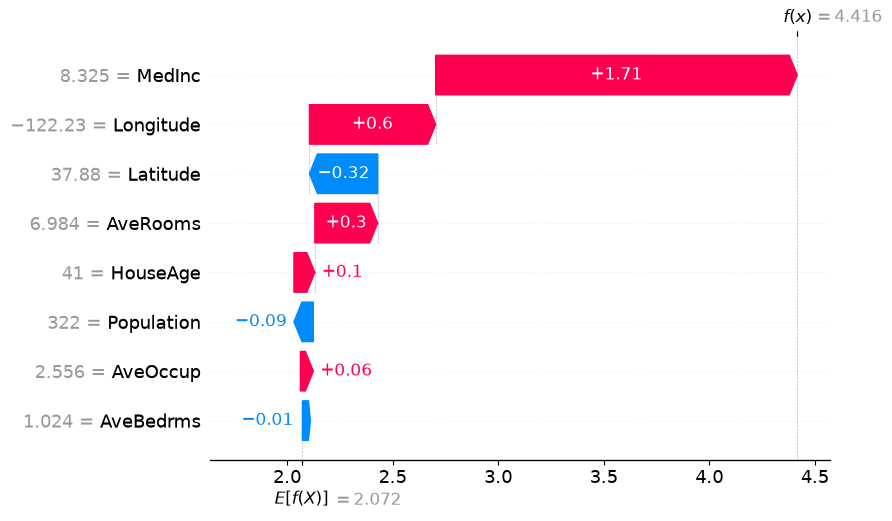

In [4]:
try:
    explainer = shap.Explainer(model)
except TypeError as exc:
    if "link" not in str(exc):
        raise
    explainer = shap.TreeExplainer(model)

shap_values = explainer(X)

shap.plots.waterfall(shap_values[0])


上图里，每个特征都在把模型输出从基准值（传入训练数据上的平均模型输出）推向当前这条样本的预测值。把预测推高的特征是红色，把预测拉低的特征是蓝色。



同一条解释也可以画成 force plot（见 Nature BME 论文）。

**注意：** Cursor / VS Code 深色主题里，交互版 JS force（`shap.plots.force(...)`）经常出现**黑底黑字**看不清。  
请用下面的 **`matplotlib=True` 静态版**。要对比两个点，就画两次静态 force，不要用 `force(shap_values[:2])` 的交互叠图。


In [5]:
# 交互 JS 版：在 Cursor 深色主题里可能黑底黑字，可跳过
# shap.plots.initjs()
# shap.plots.force(shap_values[0])


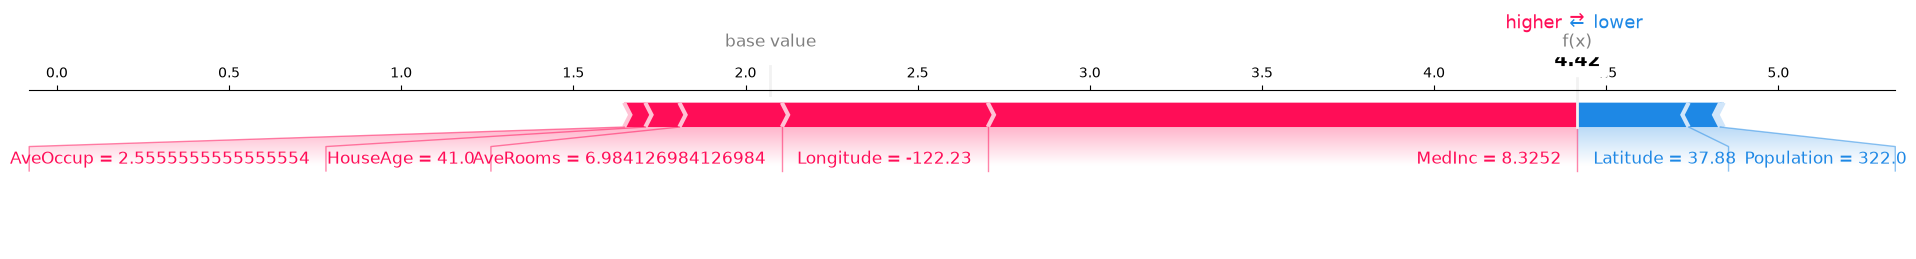

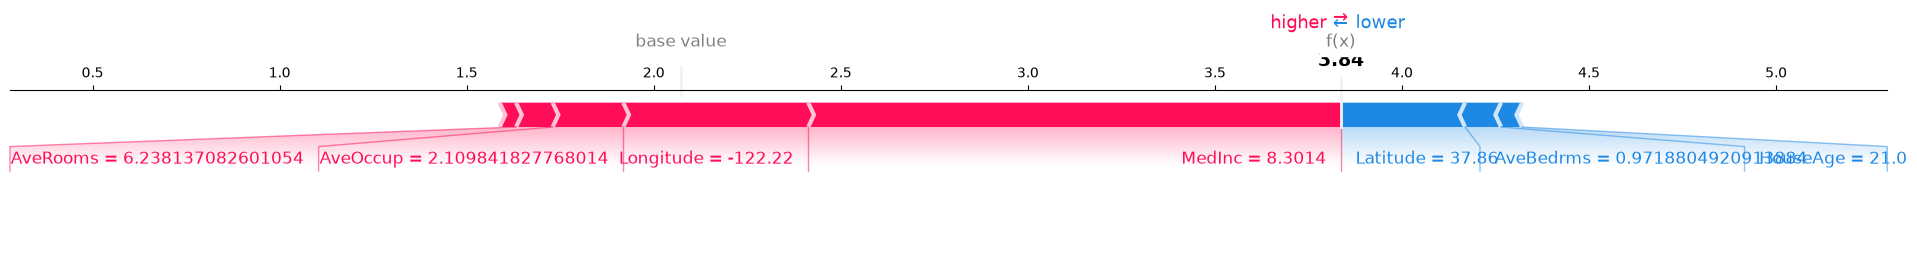

In [6]:
# 静态 force：白底，适合 Cursor；对比两个样本就画两次
shap.plots.force(shap_values[0], matplotlib=True, show=False)
plt.tight_layout()
plt.show()

shap.plots.force(shap_values[1], matplotlib=True, show=False)
plt.tight_layout()
plt.show()


官方 README 还会把很多条 force 旋转 90 度后横向叠在一起（交互图）。  
在 Cursor 深色主题里这张 JS 叠图同样容易看不清；需要时再取消下面注释，或改用 Jupyter Lab / 浏览器打开。


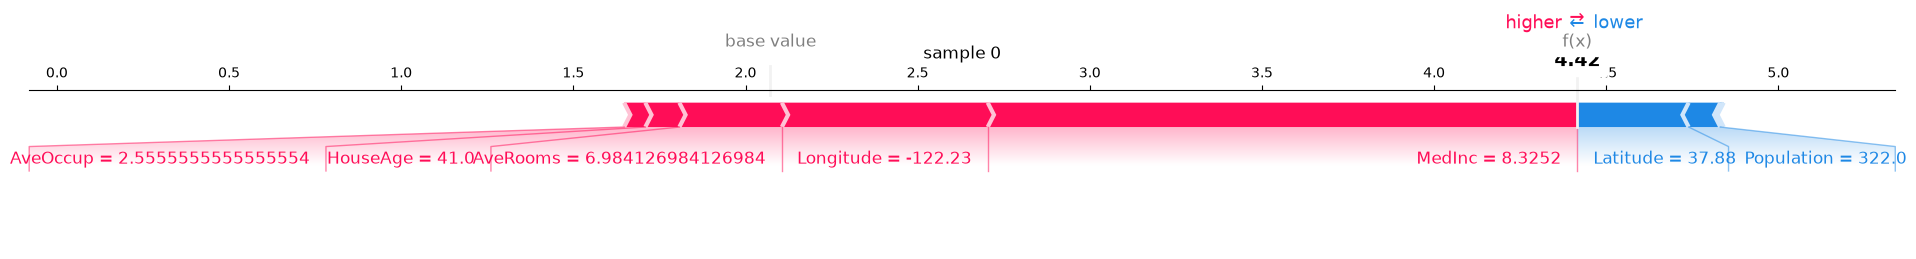

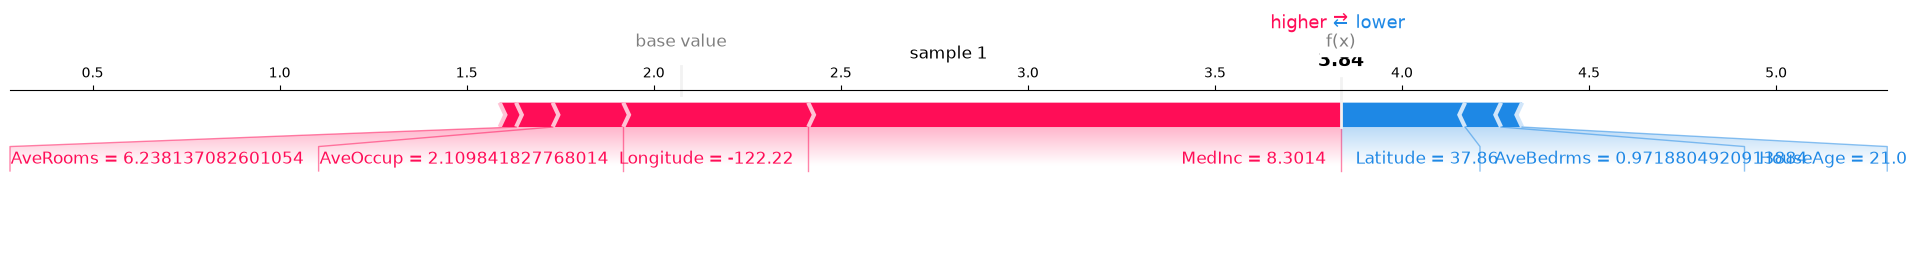

In [7]:
# 交互叠图（Cursor 深色主题可能看不清，可选）
# shap.plots.initjs()
# shap.plots.force(shap_values[:500])

# 若只想对比少数几条，用静态 force 逐条画更清楚：
for i in [0, 1]:
    shap.plots.force(shap_values[i], matplotlib=True, show=False)
    plt.title(f"sample {i}")
    plt.tight_layout()
    plt.show()


## 单个特征如何影响模型输出

把某个特征的 SHAP 值对这个特征的取值画出来，就能看它在整个数据集上的作用。SHAP 值表示该特征对模型输出变化所承担的责任，所以下图表示预测房价如何随纬度变化。

同一个纬度上的纵向分散来自与其他特征的交互。把整个 explanation 传给 `color`，散点图会自动选一个最能揭示交互的特征来着色。在这个例子里，它会选 Longitude。

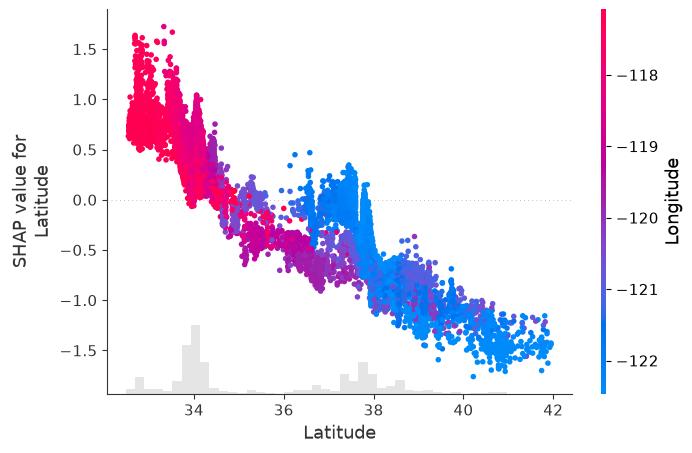

In [8]:
shap.plots.scatter(shap_values[:, "Latitude"], color=shap_values)

## 哪些特征整体上最重要

把每个特征、每条样本的 SHAP 值画在一起，可以总览特征重要性。下图按所有样本上 SHAP 绝对值之和排序，并用 SHAP 值展示每个特征对模型输出的影响分布。颜色表示特征值（红高、蓝低）。例如，更高的收入中位数会提高预测房价。

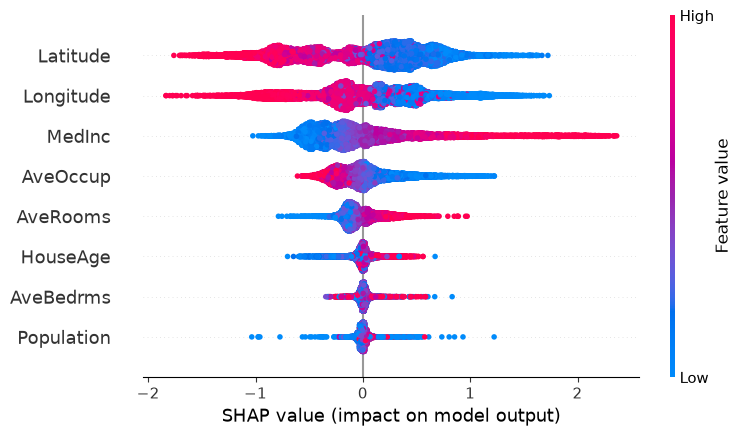

In [9]:
shap.plots.beeswarm(shap_values)

也可以只取每个特征 SHAP 值的平均绝对值，得到常规的条形图。多分类输出时，这张图会画成堆叠条形。

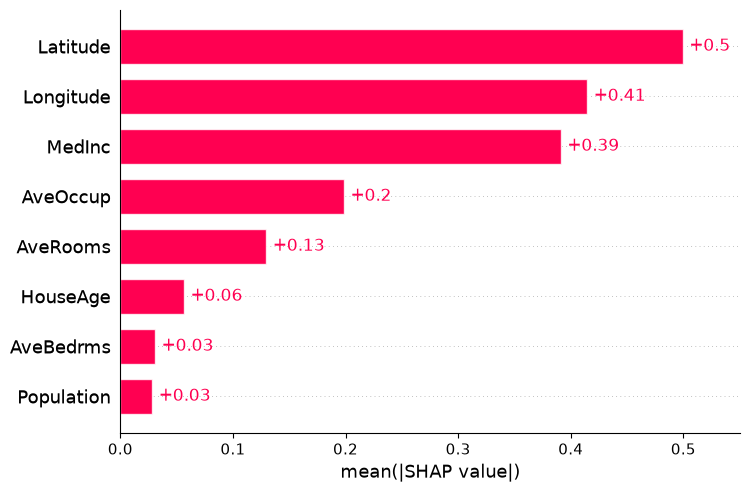

In [10]:
shap.plots.bar(shap_values)

## SHAP interaction values：特征之间的共同作用

蜂群图和 bar 主要看**单特征主效应**。若要问「A 的贡献是否取决于 B」，需要 **SHAP interaction values**。

对树模型，`TreeExplainer.shap_interaction_values` 对每个样本返回矩阵：
- **对角**：主效应
- **非对角**：成对交互

下面用前 2000 条样本以加快计算，并画出平均绝对交互热力图与最强的几对。

Top pairwise interactions (mean |SHAP interaction|):
  Latitude     x Longitude     0.1833
  MedInc       x Latitude      0.0431
  MedInc       x AveOccup      0.0411
  MedInc       x Longitude     0.0357
  MedInc       x AveRooms      0.0333
  MedInc       x HouseAge      0.0309
  AveOccup     x Latitude      0.0275
  HouseAge     x AveOccup      0.0248


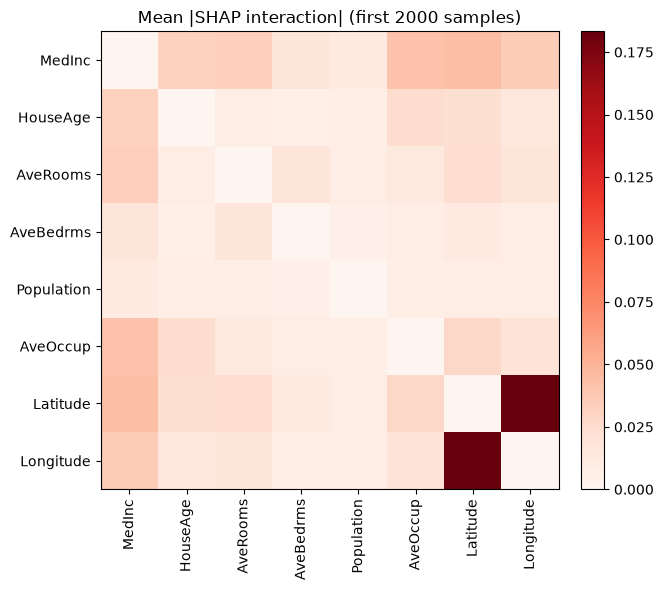

In [11]:
import numpy as np
import pandas as pd

n_inter = 2000
X_inter = X.iloc[:n_inter]
tree_explainer = shap.TreeExplainer(model)
shap_interaction = tree_explainer.shap_interaction_values(X_inter)
# (n_samples, n_features, n_features)

mean_abs_inter = np.abs(shap_interaction).mean(axis=0)
mean_abs_main = np.diag(mean_abs_inter).copy()
mean_abs_pair = mean_abs_inter.copy()
np.fill_diagonal(mean_abs_pair, 0)

feat_names = list(X.columns)
pairs = []
for i in range(len(feat_names)):
    for j in range(i + 1, len(feat_names)):
        pairs.append((float(mean_abs_pair[i, j]), feat_names[i], feat_names[j]))
pairs.sort(reverse=True)

print("Top pairwise interactions (mean |SHAP interaction|):")
for strength, a, b in pairs[:8]:
    print(f"  {a:12s} x {b:12s}  {strength:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(mean_abs_pair, cmap="Reds")
ax.set_xticks(range(len(feat_names)))
ax.set_yticks(range(len(feat_names)))
ax.set_xticklabels(feat_names, rotation=90)
ax.set_yticklabels(feat_names)
ax.set_title(f"Mean |SHAP interaction| (first {n_inter} samples)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

对最强的一对（加州房价上通常是 **Latitude × Longitude**），画 interaction dependence：横轴是第一个特征取值，纵轴是该对的交互 SHAP，颜色是第二个特征。

Plotting interaction dependence: Latitude x Longitude (0.1833)


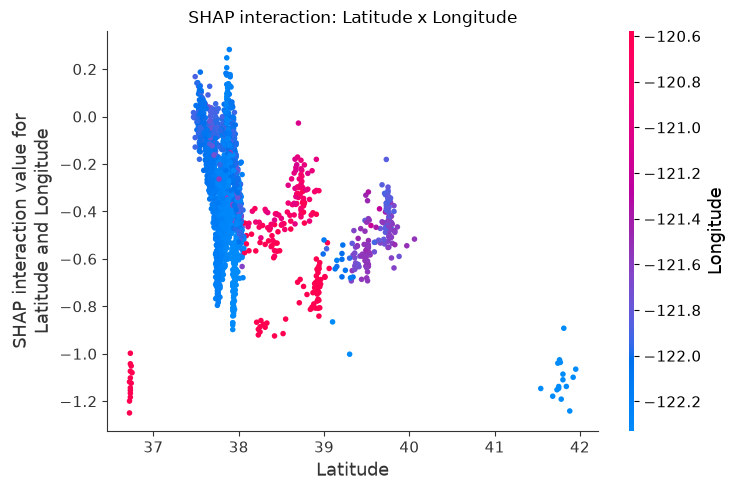

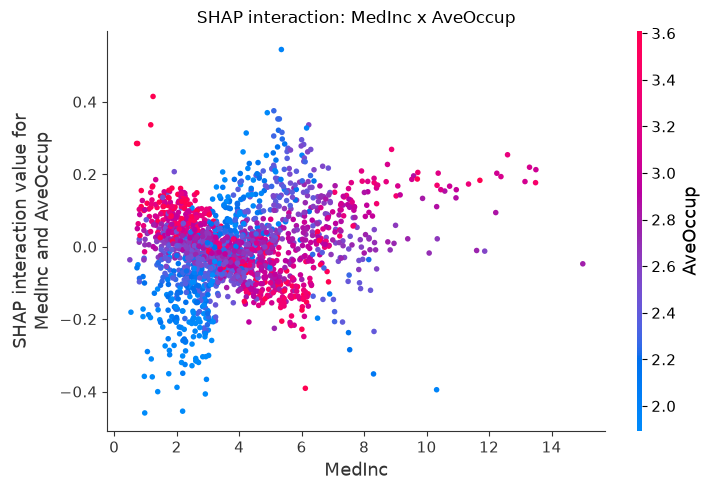

In [12]:
# 取交互最强的一对
top_strength, feat_a, feat_b = pairs[0]
print(f"Plotting interaction dependence: {feat_a} x {feat_b} ({top_strength:.4f})")

shap.dependence_plot(
    (feat_a, feat_b),
    shap_interaction,
    X_inter,
    show=False,
)
plt.title(f"SHAP interaction: {feat_a} x {feat_b}")
plt.tight_layout()
plt.show()

# 再看一个常见组合：收入 x 居住密度
shap.dependence_plot(
    ("MedInc", "AveOccup"),
    shap_interaction,
    X_inter,
    show=False,
)
plt.title("SHAP interaction: MedInc x AveOccup")
plt.tight_layout()
plt.show()

## Clustering by explanation similarity：按解释方式分群

这里不按原始特征聚类，而按每条样本的 **SHAP 向量**聚类。  
同一簇 ≈ 模型用**相似的理由**给出预测（例如都是「湾区位置抬价 + 高收入」）。

步骤：对全量 `shap_values` 做 KMeans → 看每簇的平均 SHAP 剖面 → PCA 把解释空间投到 2D。

Mean SHAP profile by cluster:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
cluster                                                                
0        -0.277    -0.002    -0.021      0.000      -0.001    -0.004   
1        -0.156    -0.008    -0.062      0.003       0.002    -0.067   
2         0.128     0.040    -0.033      0.009       0.004     0.160   
3         1.246     0.016     0.212      0.021       0.002     0.032   

         Latitude  Longitude  
cluster                       
0          -0.759      0.215  
1           0.412     -0.361  
2          -0.038      0.677  
3           0.301      0.105  

Cluster size and mean prediction / label:
            n  mean_pred  mean_y
cluster                         
0        5892      1.223   1.212
1        9324      1.837   1.831
2        3376      3.019   3.044
3        2048      4.007   4.006


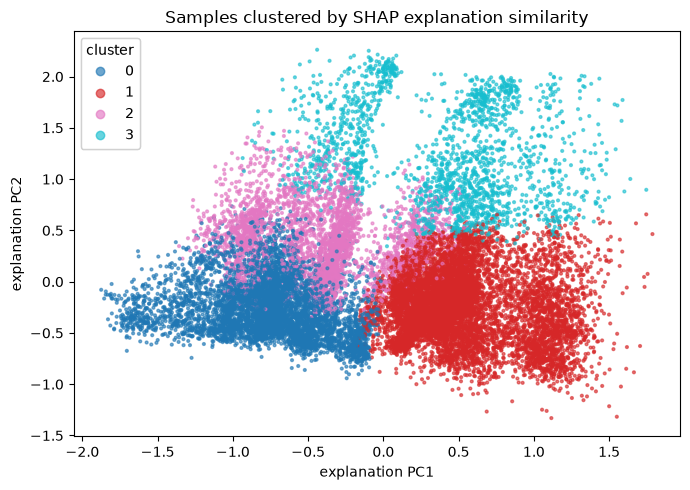

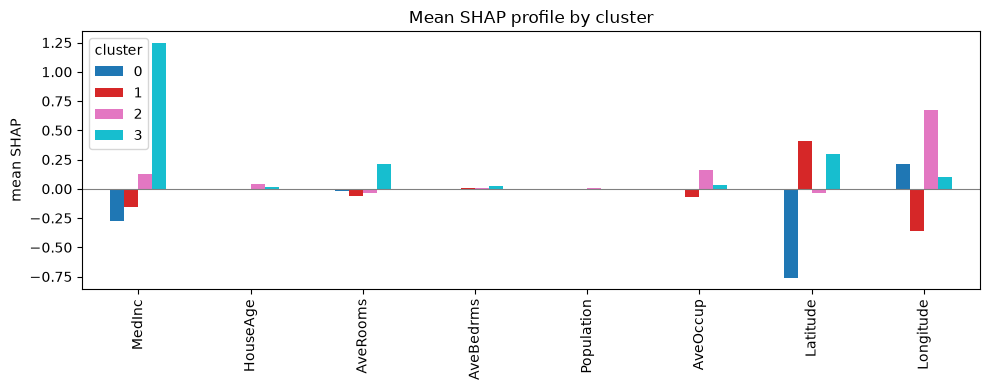

In [13]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sv = shap_values.values  # (n_samples, n_features)
n_clusters = 4
labels = KMeans(n_clusters=n_clusters, random_state=0, n_init=10).fit_predict(sv)

profile = pd.DataFrame(sv, columns=X.columns)
profile["cluster"] = labels
cluster_profile = profile.groupby("cluster").mean().round(3)
print("Mean SHAP profile by cluster:")
print(cluster_profile)

preds = model.predict(X)
summary = (
    pd.DataFrame({"cluster": labels, "pred": preds, "y": y})
    .groupby("cluster")
    .agg(n=("y", "size"), mean_pred=("pred", "mean"), mean_y=("y", "mean"))
    .round(3)
)
print("\nCluster size and mean prediction / label:")
print(summary)

# 解释空间 PCA
xy = PCA(n_components=2, random_state=0).fit_transform(sv)
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(xy[:, 0], xy[:, 1], c=labels, s=4, cmap="tab10", alpha=0.6)
ax.set_xlabel("explanation PC1")
ax.set_ylabel("explanation PC2")
ax.set_title("Samples clustered by SHAP explanation similarity")
legend = ax.legend(*sc.legend_elements(), title="cluster", loc="best")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

# 每簇平均 SHAP 剖面条形图
cluster_profile.T.plot(kind="bar", figsize=(10, 4), colormap="tab10")
plt.axhline(0, color="gray", linewidth=0.8)
plt.ylabel("mean SHAP")
plt.title("Mean SHAP profile by cluster")
plt.tight_layout()
plt.show()

可选：对某一簇单独画 beeswarm，比较「不同解释原型」的特征贡献分布。

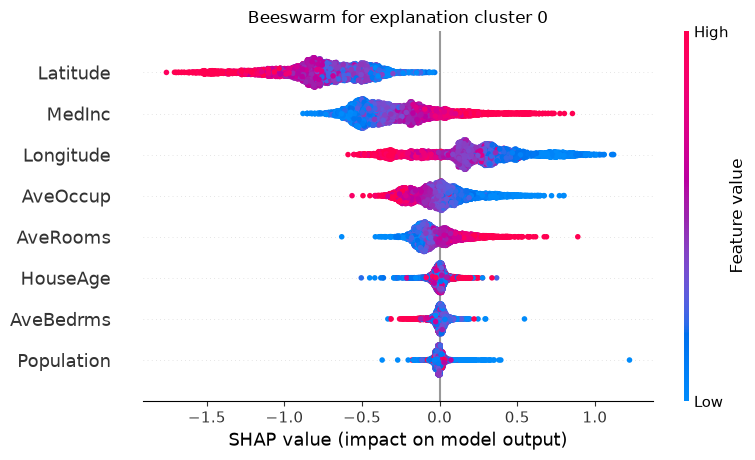

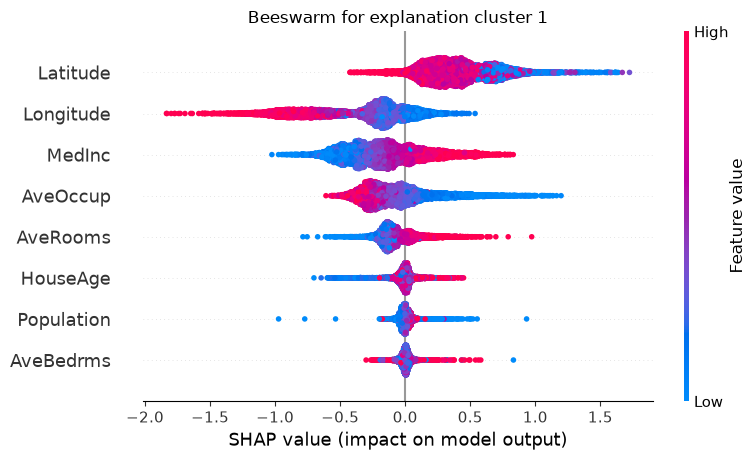

In [14]:
# 示例：看 cluster 0 与 cluster 1 的解释分布
for k in [0, 1]:
    shap.plots.beeswarm(shap_values[labels == k], max_display=8, show=False)
    plt.title(f"Beeswarm for explanation cluster {k}")
    plt.tight_layout()
    plt.show()